# SENG 5360 — Intelligent Control
## Session 2: Eigenvalues, phase portraits, controllability, and the linear toolbox

**Dr. Gerardo Flores — Texas A&M International University**

This notebook combines Codes **2.1–2.6** in slide order. Shared imports are placed once at the beginning so that the notebook runs from top to bottom.

### Google Colab
Open the notebook in Colab and select **Runtime → Run all**. NumPy, SciPy, and Matplotlib are normally preinstalled.

## Shared imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import solve_ivp

## Code 2.1 — For a real eigenvalue, the sign decides

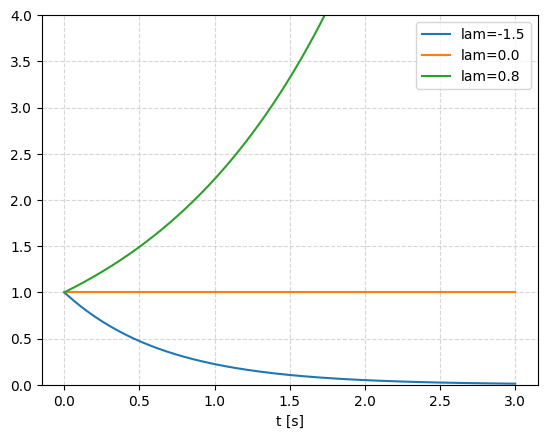

In [24]:
# Create 400 time points from 0 to 3 seconds
t = np.linspace(0, 3, 400)

# Plot e^(lambda*t) for three eigenvalue values
for lam in [-1.5, 0.0, 0.8]:   # <-- change these values
    plt.plot(t, np.exp(lam*t), label=f"lam={lam}")

# Format and display the plot
plt.ylim(0, 4)
plt.xlabel("t [s]")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Code 2.2 — Complex eigenvalues mean oscillation

[-0.6+4.j -0.6-4.j]


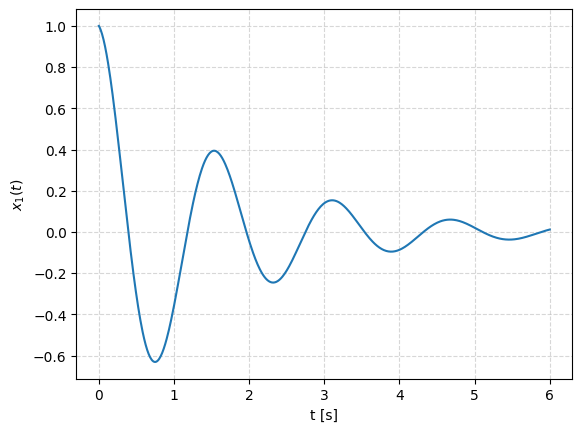

In [25]:
# Choose the real and imaginary parts of the eigenvalues
sig, wd = -0.6, 4.0            # <-- change these values

# Define A with eigenvalues sig ± j*wd
A = np.array([[ sig,  wd],
              [-wd,  sig]])

# Compute and display the eigenvalues of A
print(np.linalg.eigvals(A))

# Simulate x_dot = A x from t = 0 to 6
sol = solve_ivp(
    lambda t, x: A @ x,        # Differential equation
    [0, 6],                    # Simulation interval
    [1.0, 0.0],                # Initial state x(0)
    max_step=0.01
)

# Plot the first state x1(t)
plt.plot(sol.t, sol.y[0])
plt.xlabel("t [s]")
plt.ylabel(r"$x_1(t)$")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Code 2.3 — Drawing a phase portrait yourself

[-1.+2.j -1.-2.j]


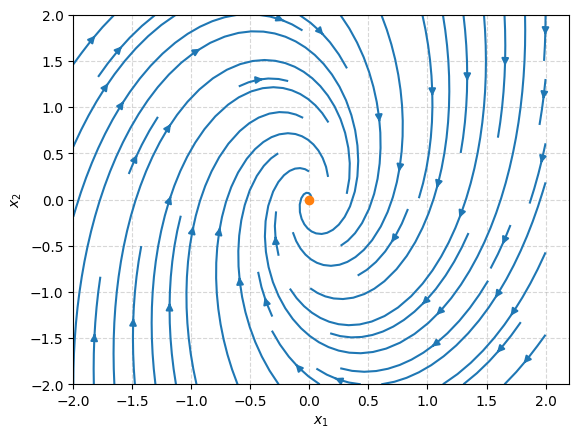

In [26]:
# Define the system matrix for x_dot = A x
A = np.array([[-1.0,  1.0],      # <-- change this matrix
              [-4.0, -1.0]])

# Create a grid of points in the state plane
g = np.linspace(-2, 2, 300)
X1, X2 = np.meshgrid(g, g)

# Evaluate x_dot = A x at every point of the grid
DX1 = A[0, 0]*X1 + A[0, 1]*X2
DX2 = A[1, 0]*X1 + A[1, 1]*X2

# Draw the phase portrait
plt.streamplot(X1, X2, DX1, DX2, density=0.8)
plt.plot(0, 0, "o")              # Mark the equilibrium

# Label the axes and display the eigenvalues
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
print(np.linalg.eigvals(A))

# Format and display the plot
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Code 2.4 — When can the eigenvalues be placed at all?

The original code uses matrices `A` and `B` defined elsewhere. To make this notebook executable from top to bottom, the following cell reuses the `A` and `B` values from Code 2.5.

In [27]:
# Define the system matrices: x_dot = A x + B u, where x has dimension 'n'
A = np.array([[ 0.0,  1.0],
              [-2.0, -3.0]])

B = np.array([[0.0],
              [1.0]])

# Build the controllability matrix [B, AB, ..., A^(n-1)B]
def ctrb(A, B):
    n = A.shape[0]              # Number of states
    return np.hstack(
        [np.linalg.matrix_power(A, k) @ B
         for k in range(n)]
    )

# Compute its rank; rank = n means the system is controllable
print(np.linalg.matrix_rank(ctrb(A, B)))   # Output: 2

2


## Code 2.5 — Lab 2: the linear toolbox

[-1. -2.]
[[ 0.84518188  0.23865122]
 [-0.47730244  0.12922822]]


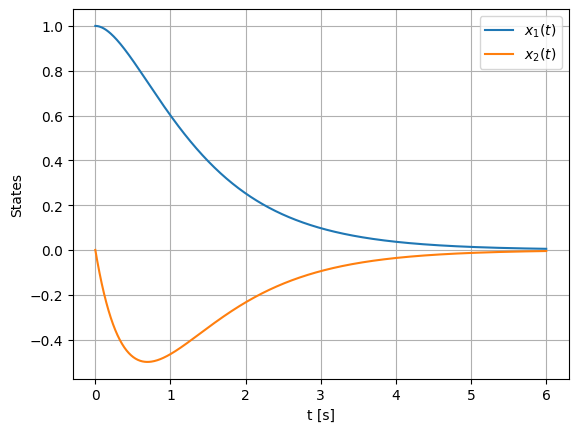

In [23]:
# System matrices: x_dot = A x + B u
A = np.array([[ 0.0,  1.0],
              [-2.0, -3.0]])

B = np.array([[0.0],
              [1.0]])          # Input matrix; not used in this simulation

# Compute and display the eigenvalues of A
print(np.linalg.eigvals(A))    # Expected: -1, -2

# Compute the state-transition matrix Phi(0.5) = e^(A*0.5)
print(expm(A * 0.5))

# Numerically simulate x_dot = A x
sol = solve_ivp(
    lambda t, x: A @ x,        # Differential equation
    [0, 6],                    # Simulation interval
    [1.0, 0.0],                # Initial state x(0)
    max_step=0.01              # Maximum integration step
)

# Print the solution of x_dot = A x
plt.plot(sol.t, sol.y[0], label=r"$x_1(t)$")
plt.plot(sol.t, sol.y[1], label=r"$x_2(t)$")
plt.xlabel("t [s]")
plt.ylabel("States")
plt.grid(True)
plt.legend()
plt.show()

## Code 2.6 — Lab 2: what to do

[-2.1+2.14242853j -2.1-2.14242853j]


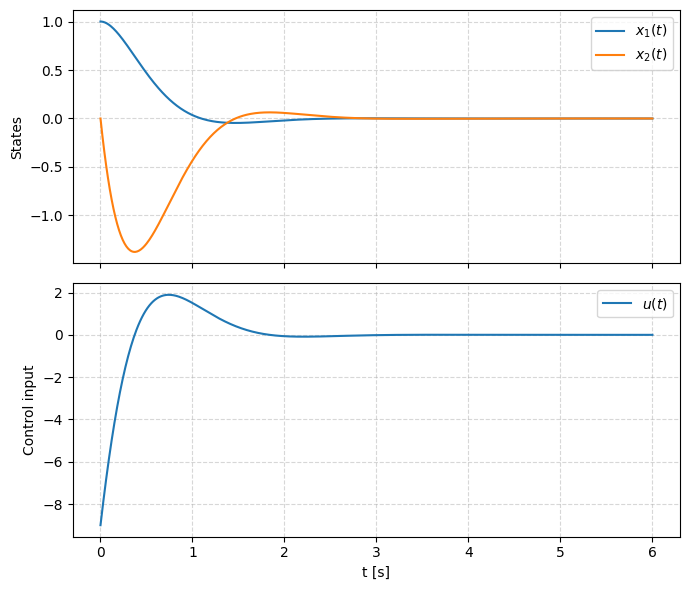

In [29]:
# Double-integrator model: x_dot = A x + B u
A = np.array([[0.0, 1.0],
              [0.0, 0.0]])

B = np.array([[0.0],
              [1.0]])

# State-feedback controller: u = -Kx
K = np.array([[9.0, 4.2]])

# Closed-loop matrix
Acl = A - B @ K

# Display the closed-loop eigenvalues
print(np.linalg.eigvals(Acl))

# Simulate the closed-loop system
sol = solve_ivp(
    lambda t, x: Acl @ x,
    [0, 6],
    [1.0, 0.0],
    max_step=0.01
)

# Compute the control input along the trajectory
u = -(K @ sol.y).ravel()

# Plot the states and control input
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7, 6))

# States
ax[0].plot(sol.t, sol.y[0], label=r"$x_1(t)$")
ax[0].plot(sol.t, sol.y[1], label=r"$x_2(t)$")
ax[0].set_ylabel("States")
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].legend()

# Control input
ax[1].plot(sol.t, u, label=r"$u(t)$")
ax[1].set_xlabel("t [s]")
ax[1].set_ylabel("Control input")
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()